In [2]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import shapely
import numpy as np
import fiona

%matplotlib inline
%config InlineBackend.figure_format = "retina"

### Section One: computing "gerrymandering scores" and building the data frame

In [3]:
# congressional district boundaries cong116 data set: https://www.census.gov/geographies/mapping-files/2018/geo/carto-boundary-file.html
dists_map = gpd.read_file("data_2018/cb_2018_us_cd116_500k.shp", engine="fiona")

# congressional district election data set: https://github.com/PrincetonUniversity/gerrymandertests/tree/master/election_data
dists_demo = gpd.read_file("data_2018/congressional_election_results_post1948.csv", engine="fiona")

In [4]:
# remove data from years besides 2018
dists_demo = dists_demo[dists_demo["Year"] == "2018"]
dists_demo["codes"] = dists_demo["State"] + dists_demo["District"]
dists_demo = dists_demo.drop(columns = ["State", "District"])

In [5]:
# functions to compute and plot convex hull
# input state, district number as strings
def comp_hull(state, d):
    dist = dists_map[(dists_map["State"] == state) & (dists_map["District"] == d)]
    hull = dist.convex_hull
    return(hull)

def plot_hull(state, d):
    hull = comp_hull(state, d)
    hull.plot(figsize = (20, 20))

# compute region of convex hull outside of the district
def hull_overlap(state, d):
    dist = dists_map[(dists_map["State"] == state) & (dists_map["District"] == d)]
    hull = dist.convex_hull
    overlap = hull.difference(dist)
    return(overlap)

def plot_overlap(state, d):
    overlap = hull_overlap(state, d)
    overlap.plot(figsize = (20, 20))

# compute region of convex hull outside of district but within state lines
def hull_intersection(state, d):
    state_plot = dists_map[dists_map["State"] == state]
    hull = hull_overlap(state, d)
    hull_df = gpd.GeoDataFrame(geometry = hull)
    intersection = gpd.overlay(state_plot, hull_df, how="intersection", keep_geom_type = True)
    return(intersection)

def plot_intersection(state, d):
    intersection = hull_intersection(state, d)
    intersection.plot(figsize = (20, 20))

# compute area of convex hull outside of district but within state lines
def hull_area(state, d):
    hull_pts = hull_intersection(state, d)
    hull = sum(hull_pts.geometry.to_crs("epsg:32633").area)
    return(hull)

# compute ratio of area of convex hull outside of district but within state lines to area of district
# idea: higher ratio implies that the district is less convex
# this function is unnecessary as all values are stored in df
def hull_ratio(state, d):
    dist = dists_map[(dists_map["State"] == state) & (dists_map["District"] == d)]["Area"]
    hull = hull_area(state, d)
    ratio = hull / dist
    return(ratio)

In [6]:
# fips to state abbreviations
fips_to_state = {
    "01": "AL", "02": "AK", "04": "AZ", "05": "AR", "06": "CA",
    "08": "CO", "09": "CT", "10": "DE", "12": "FL", "13": "GA", 
    "15": "HI", "16": "ID", "17": "IL", "18": "IN", "19": "IA", 
    "20": "KS", "21": "KY", "22": "LA", "23": "ME", "24": "MD", 
    "25": "MA", "26": "MI", "27": "MN", "28": "MS", "29": "MO", 
    "30": "MT", "31": "NE", "32": "NV", "33": "NH", "34": "NJ", 
    "35": "NM", "36": "NY", "37": "NC", "38": "ND", "39": "OH", 
    "40": "OK", "41": "OR", "42": "PA", "44": "RI", "45": "SC", 
    "46": "SD", "47": "TN", "48": "TX", "49": "UT", "50": "VT", 
    "51": "VA", "53": "WA", "54": "WV", "55": "WI", "56": "WY"
}

dists_map["State"] = dists_map["STATEFP"].map(fips_to_state)
dists_map["District"] = list(map(lambda s: s.lstrip("0"), dists_map["CD116FP"]))
dists_map["District"] = dists_map["District"].apply(lambda x: "1" if x == "" else x)

# remove territories
dists_map = dists_map.dropna()

In [7]:
# compute all hull areas
hull_areas = []
for i in range(0, len(dists_map)):
    state = dists_map["State"].iloc[i]
    d = dists_map["District"].iloc[i]
    hull = hull_area(state, d)
    hull_areas.append(hull)

In [ ]:
# compute average

In [9]:
dists_map["geom_crs"] = dists_map["geometry"].geometry.to_crs("epsg:32633")
dists_map["Area"] = dists_map["geom_crs"].area
dists_map["hull_area"] = hull_areas
dists_map["Ratio"] = dists_map["hull_area"] / dists_map["Area"]
dists_map["codes"] = dists_map["State"] + dists_map["District"]

In [10]:
# merge dfs on state and district
dists = pd.merge(dists_demo, dists_map, on = "codes", how = "outer")
dists_geo = gpd.GeoDataFrame(dists)
dists_geo["D Voteshare"] = dists_geo["D Voteshare"].astype(float)

In [21]:
dists.sort_values(by = "Ratio").tail(10)

,Year,Dem Votes,GOP Votes,D Voteshare,Incumbent,Party,codes,STATEFP,CD116FP,AFFGEOID,...,CDSESSN,ALAND,AWATER,geometry,State,District,geom_crs,Area,hull_area,Ratio
189,2018,167201.0,77782.0,0.6825004183963785,D,D,MD2,24,02,5001600US2402,...,116,902965456,440369386,"MULTIPOLYGON (((-76.0921 39.53522, -76.09142 3...",MD,2,"MULTIPOLYGON (((-6024059.999 10144936.359, -60...",2.412542e+09,3.093271e+09,1.282162
295,2018,146687.0,0.0,1.0,D,D,NY7,36,07,5001600US3607,...,116,41801517,2679582,"POLYGON ((-74.02396 40.64233, -74.02277 40.643...",NY,7,"POLYGON ((-5834303.404 9871609.965, -5834105.3...",1.040052e+08,1.336590e+08,1.285118
272,2018,173095.0,37619.0,0.8214689104663193,D,D,NY10,36,10,5001600US3610,...,116,36381172,23227075,"MULTIPOLYGON (((-74.00296 40.69476, -74.00241 ...",NY,10,"MULTIPOLYGON (((-5825329.139 9869129.856, -582...",1.106414e+08,1.435413e+08,1.297356
387,2018,90805.0,26120.0,0.7766089373530041,D,D,TX33,48,33,5001600US4833,...,116,549099381,16592268,"POLYGON ((-97.40505 32.80521, -97.40503 32.809...",TX,33,"POLYGON ((-6120767.056 13396640.869, -6120159....",1.435844e+09,1.903785e+09,1.325900
372,2018,119992.0,139188.0,0.46296782159117217,O,R,TX2,48,02,5001600US4802,...,116,799680486,54815759,"POLYGON ((-95.64576 29.849, -95.6454 29.85217,...",TX,2,"POLYGON ((-6717469.593 13500719.167, -6717025....",2.502456e+09,3.459933e+09,1.382615
148,2018,143895.0,22294.0,0.865851530486374,O,D,IL4,17,04,5001600US1704,...,116,135804048,966145,"POLYGON ((-87.92062 41.88975, -87.92057 41.897...",IL,4,"POLYGON ((-5366208.969 11554970.143, -5365058....",2.882563e+08,3.986908e+08,1.383113
203,2018,214334.0,45899.0,0.8236234451433907,D,D,MI14,26,14,5001600US2614,...,116,480339355,97940449,"POLYGON ((-83.43929 42.56014, -83.43626 42.562...",MI,14,"POLYGON ((-5406712.17 11007935.08, -5406398.20...",1.067566e+09,1.585160e+09,1.484836
174,2018,190182.0,0.0,1.0,D,D,LA2,22,02,5001600US2202,...,116,3285174126,522407749,"POLYGON ((-91.32548 30.34681, -91.31954 30.343...",LA,2,"POLYGON ((-7036542.661 12841428.217, -7037547....",1.239493e+10,1.954778e+10,1.577079
389,2018,138278.0,50553.0,0.7322844236380679,D,D,TX35,48,35,5001600US4835,...,116,1538273012,19151538,"POLYGON ((-98.54734 29.44272, -98.5437 29.4423...",TX,35,"POLYGON ((-6478012.226 13915657.866, -6478450....",4.287454e+09,7.461464e+09,1.740302
190,2018,202407.0,82774.0,0.7097492469694685,D,D,MD3,24,03,5001600US2403,...,116,788544340,252344417,"POLYGON ((-77.15601 39.26353, -77.15607 39.264...",MD,3,"POLYGON ((-6064962.191 10290704.561, -6064754....",2.056357e+09,4.642475e+09,2.257621


In [26]:
dists[["State", "District","Ratio"]].sort_values(by = "Ratio", ascending = True).tail(10)

,State,District,Ratio
189,MD,2,1.282162
295,NY,7,1.285118
272,NY,10,1.297356
387,TX,33,1.325900
372,TX,2,1.382615
148,IL,4,1.383113
203,MI,14,1.484836
174,LA,2,1.577079
389,TX,35,1.740302
190,MD,3,2.257621


### Section two: analysing the data

<Axes: >

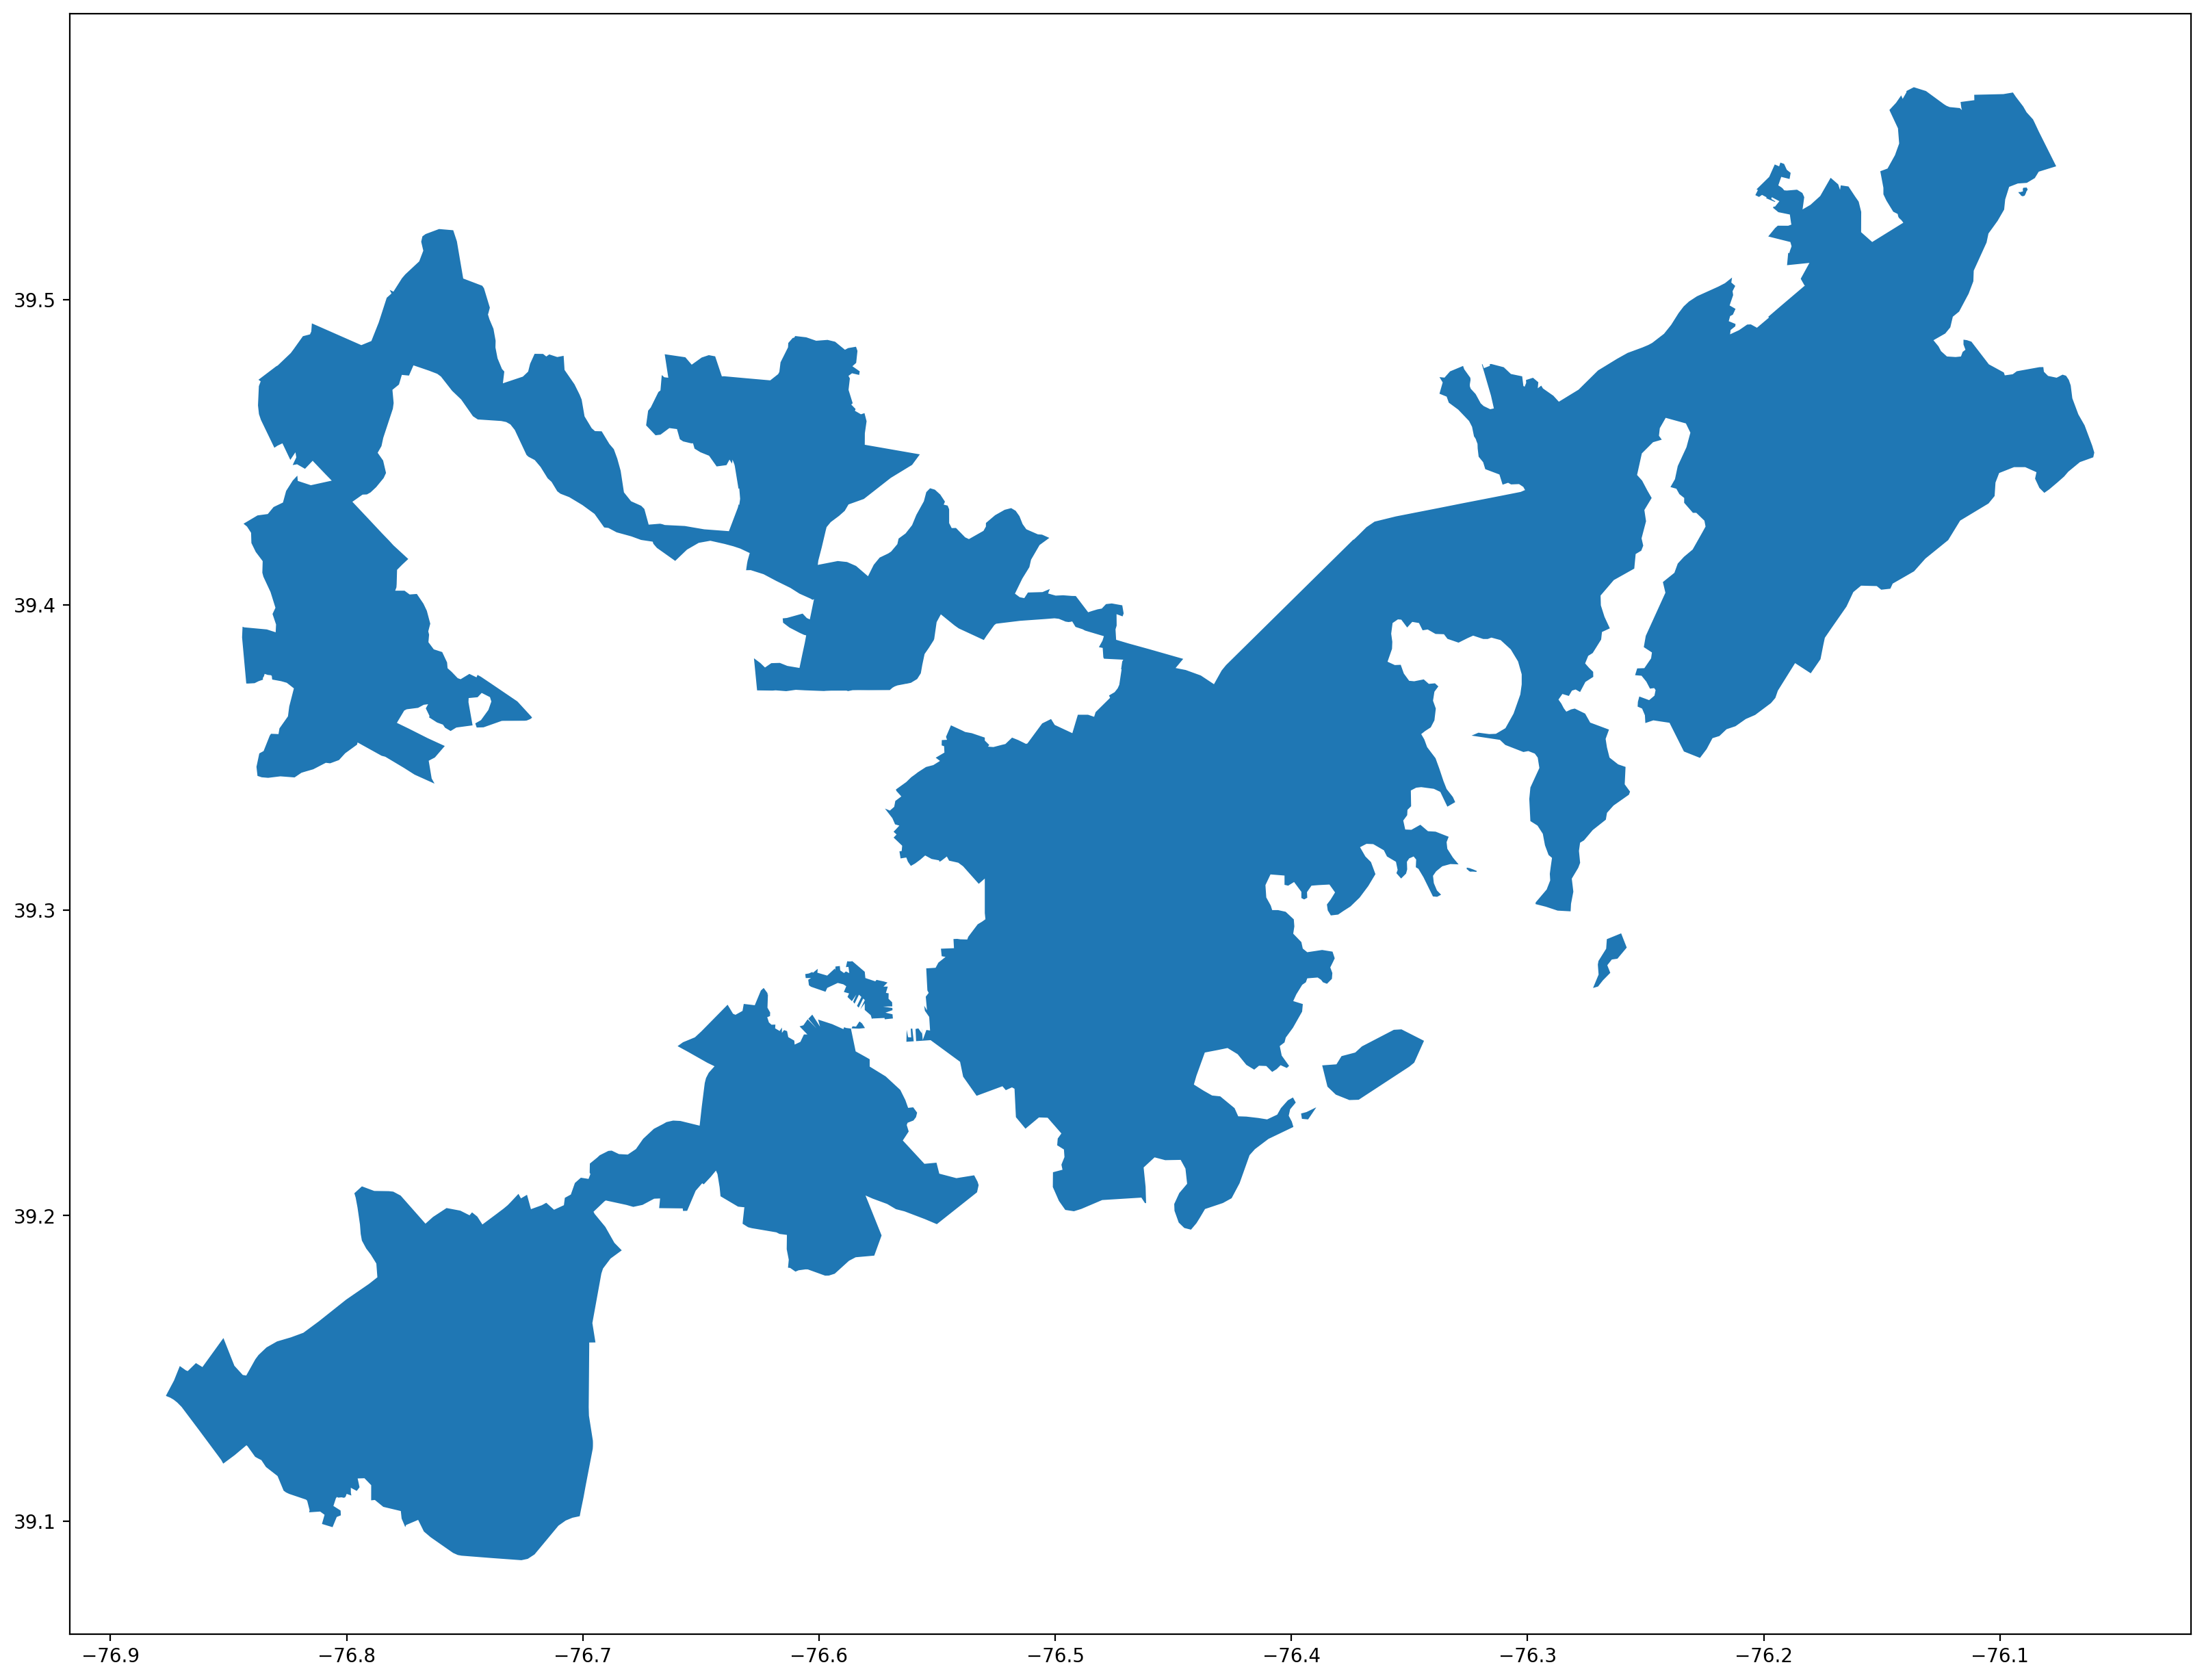

In [32]:
dists_map[(dists_map["State"] == "MD") & (dists_map["District"] == "2")].plot(figsize = (20, 20))

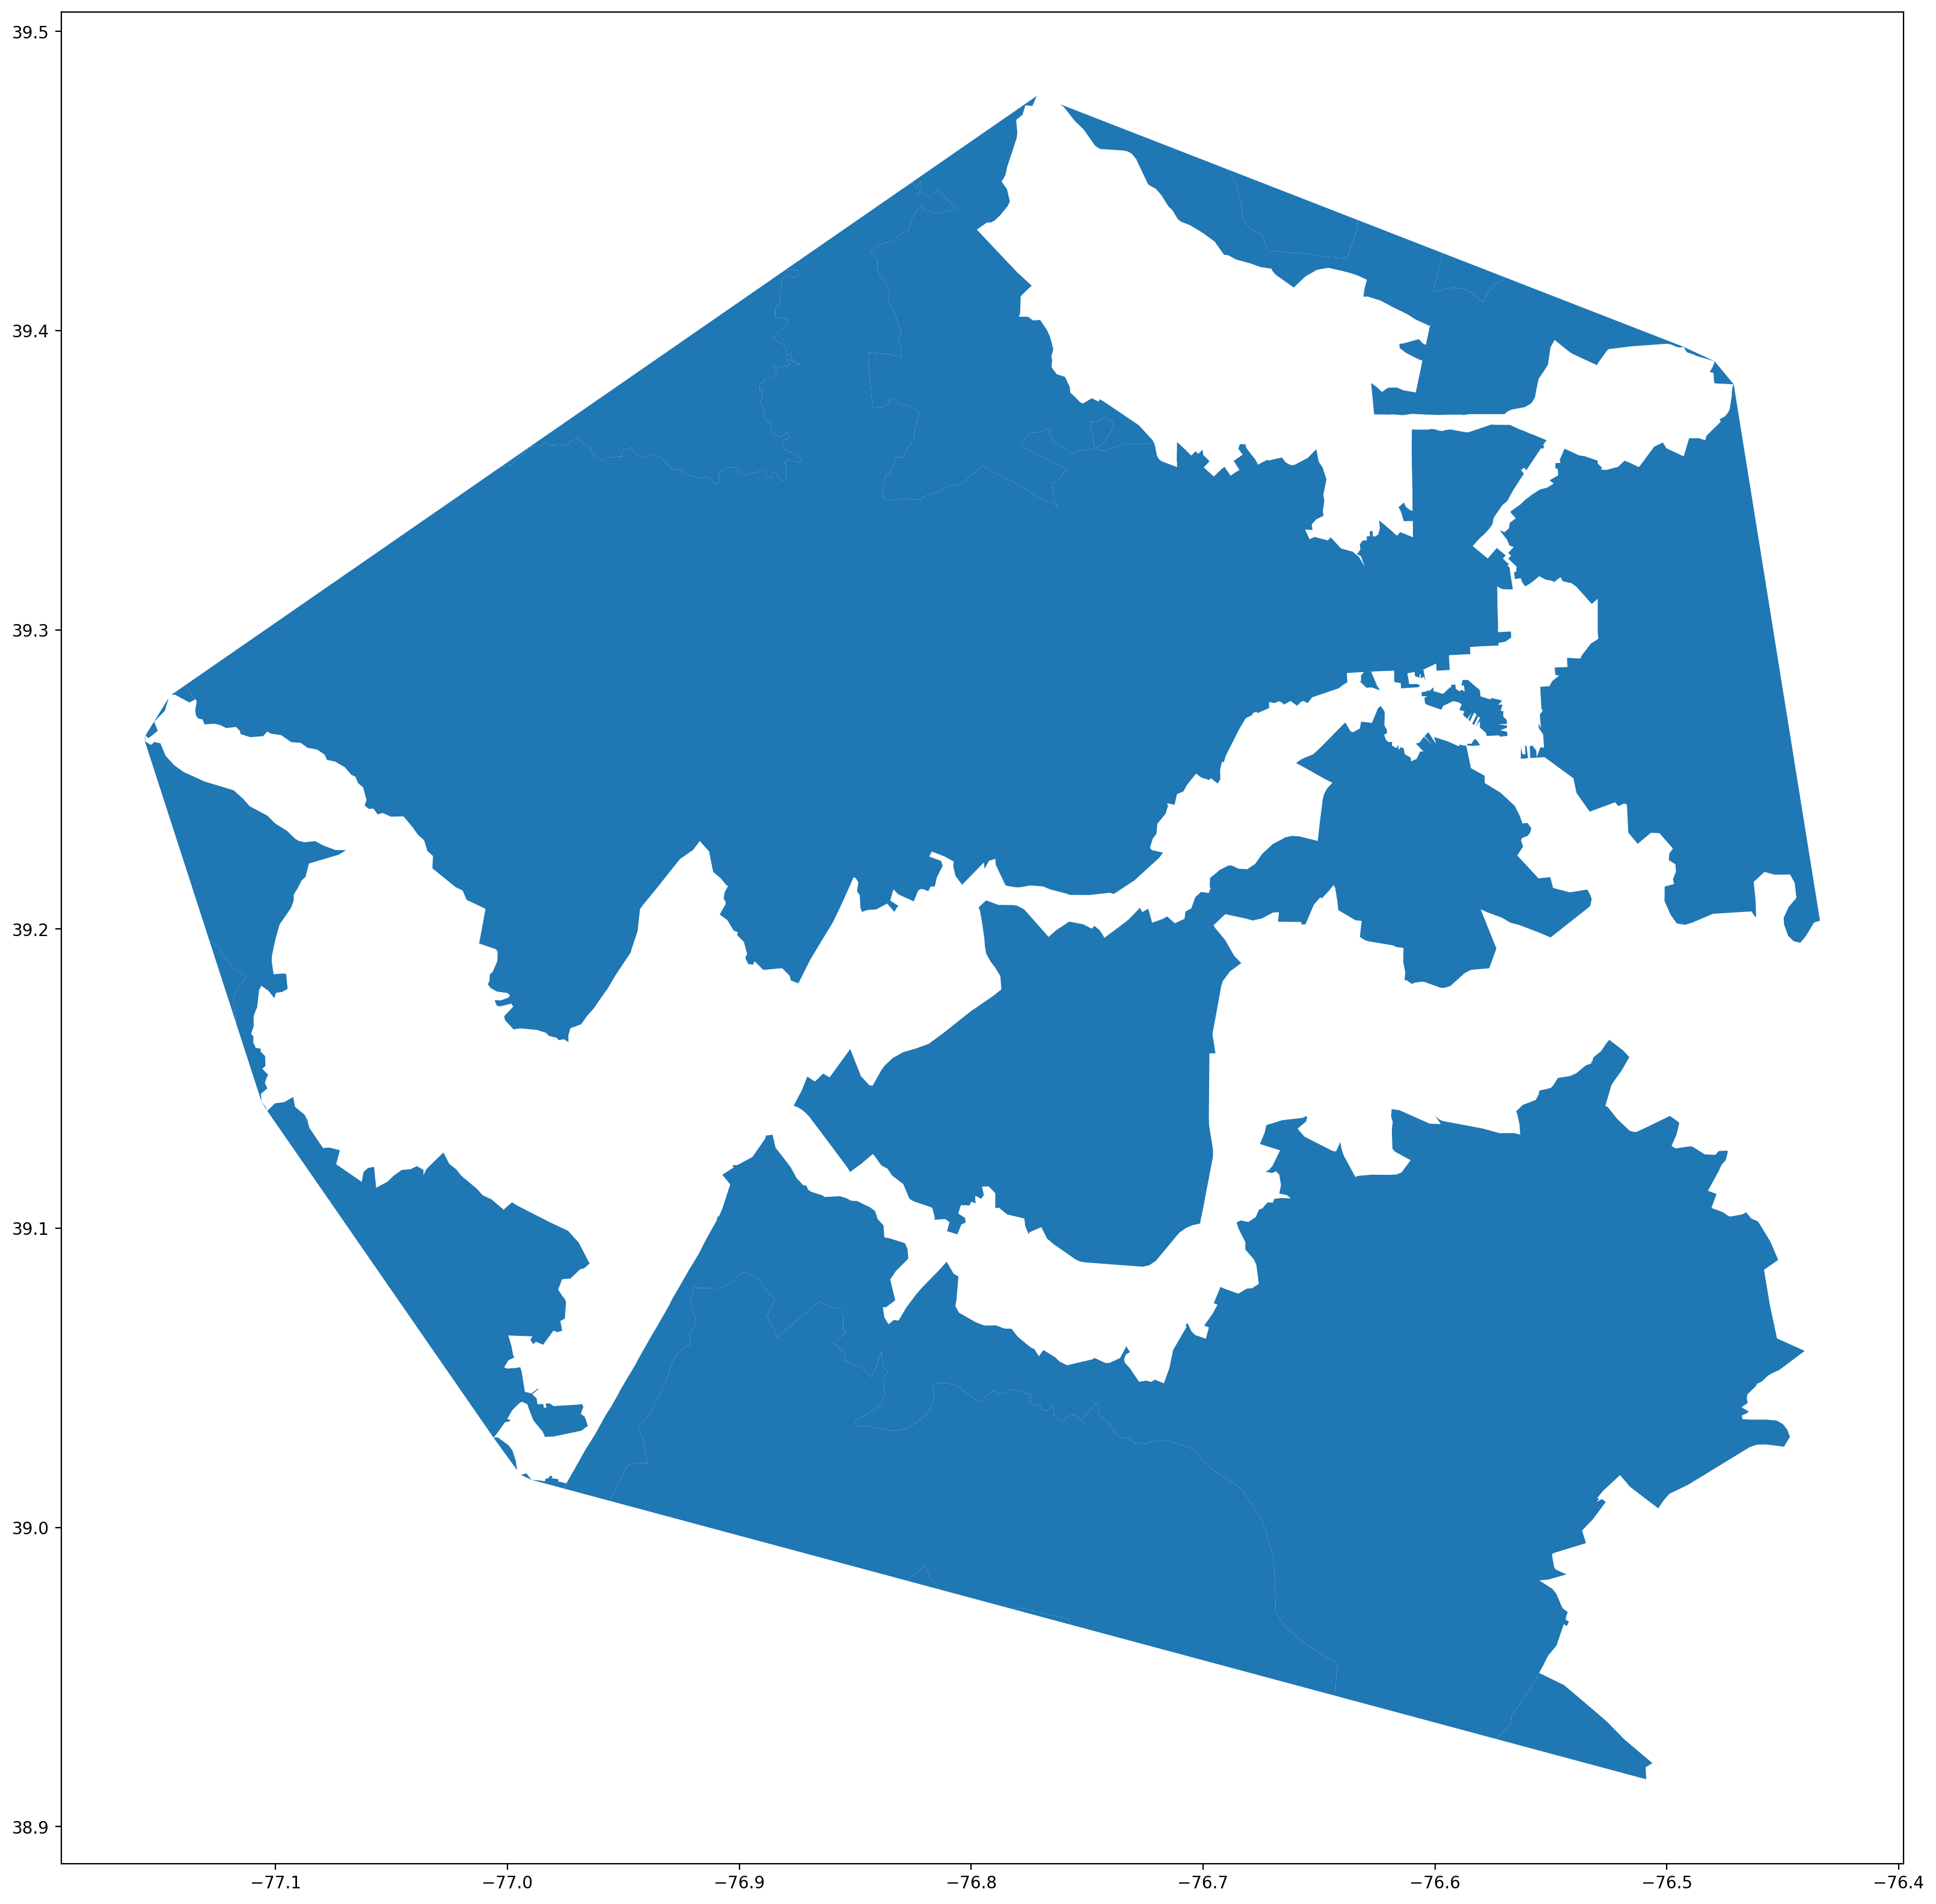

In [28]:
plot_intersection("MD", "3")

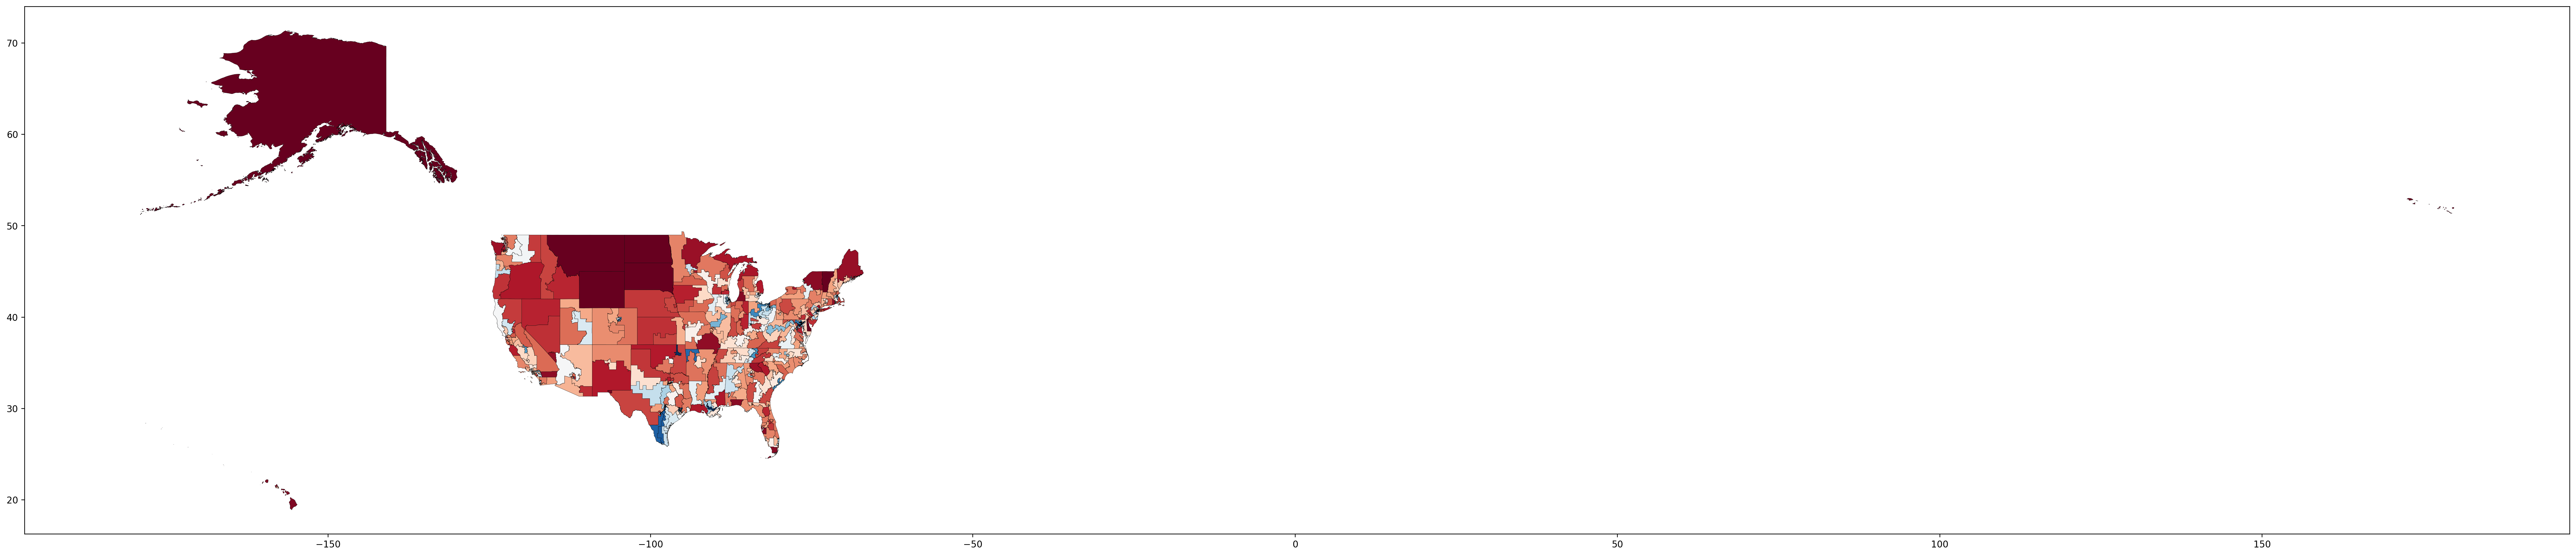

In [114]:
# plot full image with coloring
dists_map.plot(
    column="Ratio",
    #legend=True,
    figsize=(50, 50),
    edgecolor="black",
    linewidth=0.2,
    cmap = "RdBu",
    vmin = 0,
    vmax = 1
);

In [12]:
# dists_geo.plot(
#     column="D Voteshare",
#     #legend=True,
#     figsize=(100, 100),
#     edgecolor="black",
#     linewidth=0.2,
#     cmap = "RdBu",
#     vmin = 0.30,
#     vmax = 0.70
# );
dists_map.plot(
    column="Ratio",
    #legend=True,
    figsize=(100, 100),
    edgecolor="black",
    linewidth=0.2,
    cmap = "RdBu",
    vmin = 0,
    vmax = 1
);

<Axes: xlabel='D Voteshare', ylabel='Ratio'>

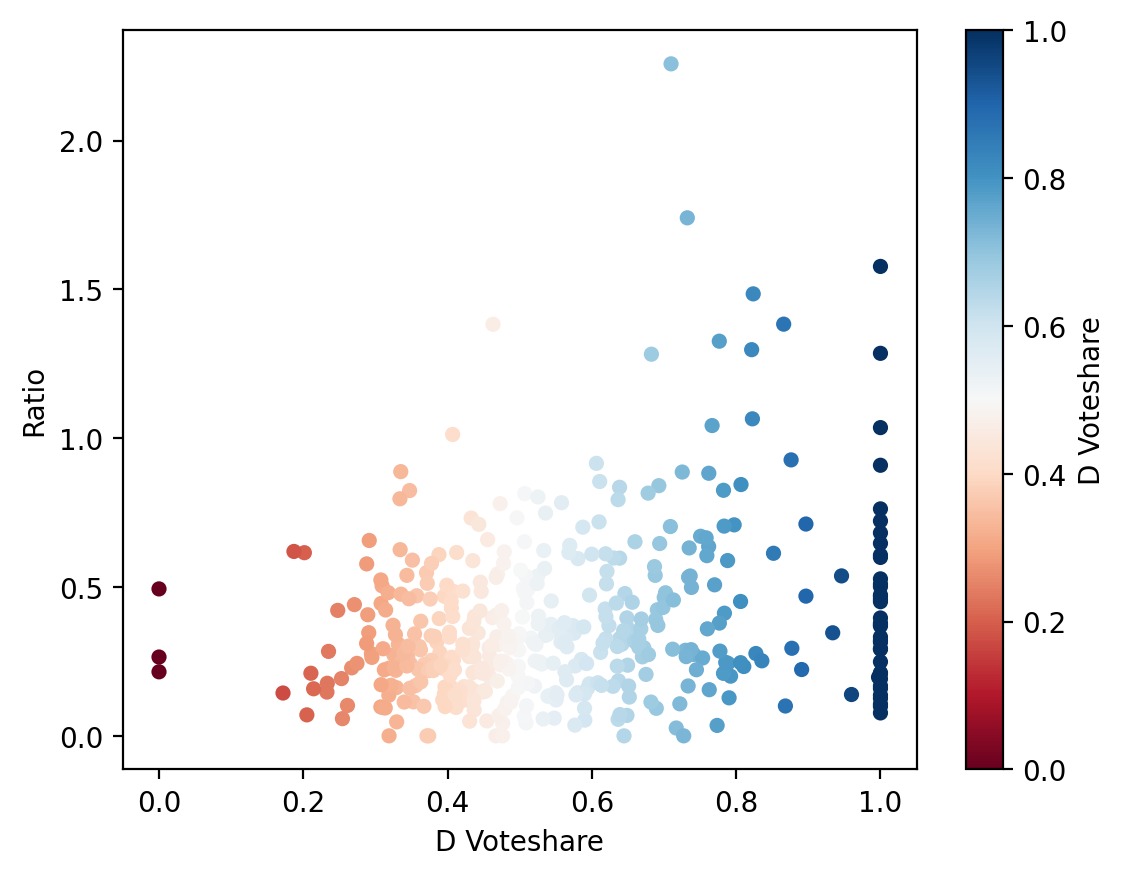

In [136]:
# compare political alignments and convexity ratios
dists_geo.plot.scatter(x = "D Voteshare", y = "Ratio", c = "D Voteshare", cmap = "RdBu")

In [15]:
dists_geo["Incumbent"].unique()

array(['R', 'D', 'O'], dtype=object)

<Axes: xlabel='D Voteshare', ylabel='Ratio'>

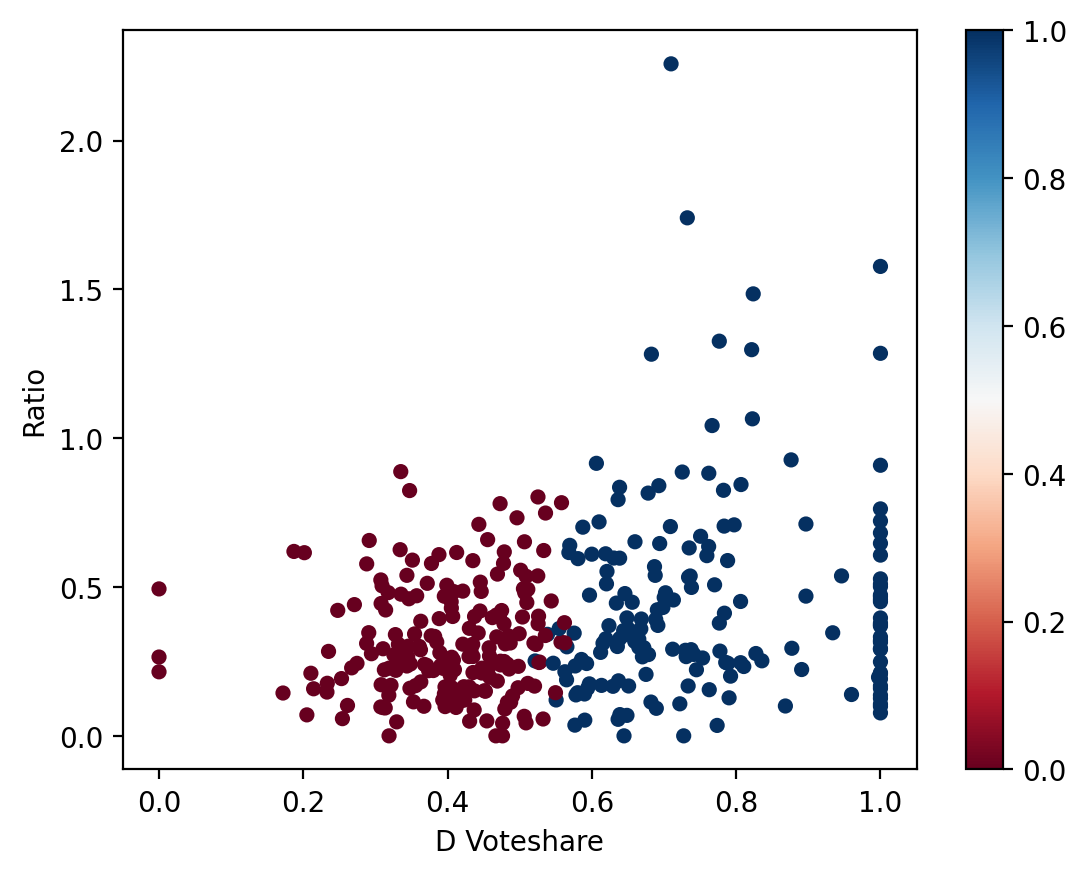

In [40]:
# color scatter plot based on incumbent party
# idea: color graph depending on agreements
# DR = democrat elected in a republican district
# RD = republican elected in a democratic district
color_map = {"D": 1, "R": 0}
colors = dists_geo["Incumbent"].map(color_map)
dists_geo.plot.scatter(x = "D Voteshare", 
                       y = "Ratio", 
                       c = colors, 
                       cmap = "RdBu",
                       vmin = 0,
                       vmax = 1)

#### Subsection a: linear regression

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

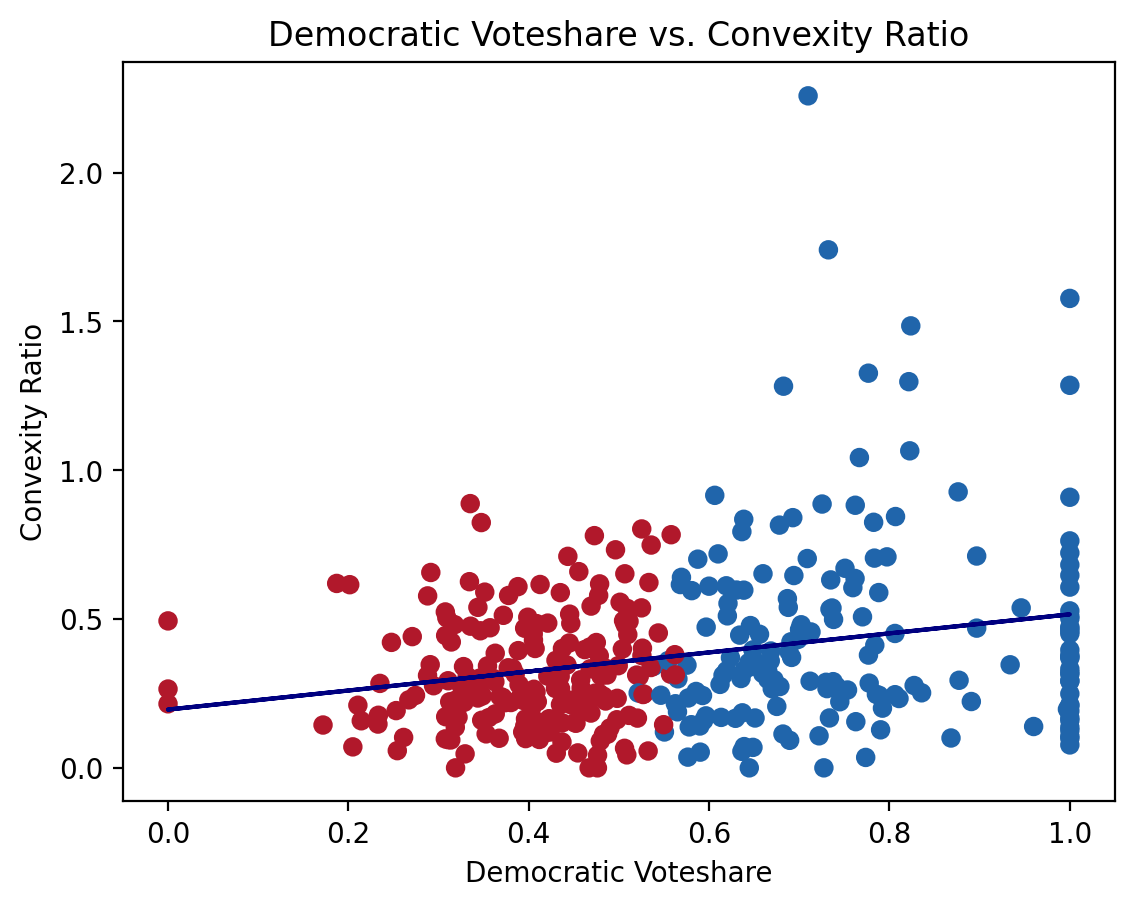

In [45]:
color_map = {"D": 0.9, "R": 0.1}
colors = dists_geo["Incumbent"].map(color_map)

x = dists_geo[["D Voteshare"]]
y = dists_geo[["Ratio"]]

regressor = LinearRegression()
regressor.fit(x, y)

plt.scatter(x, 
            y, 
            c = colors, 
            cmap = "RdBu",
            vmin = 0,
            vmax = 1)
plt.plot(x, regressor.predict(x), color = 'navy')
plt.title("Democratic Voteshare vs. Convexity Ratio")
plt.xlabel("Democratic Voteshare")
plt.ylabel("Convexity Ratio")
plt.show()

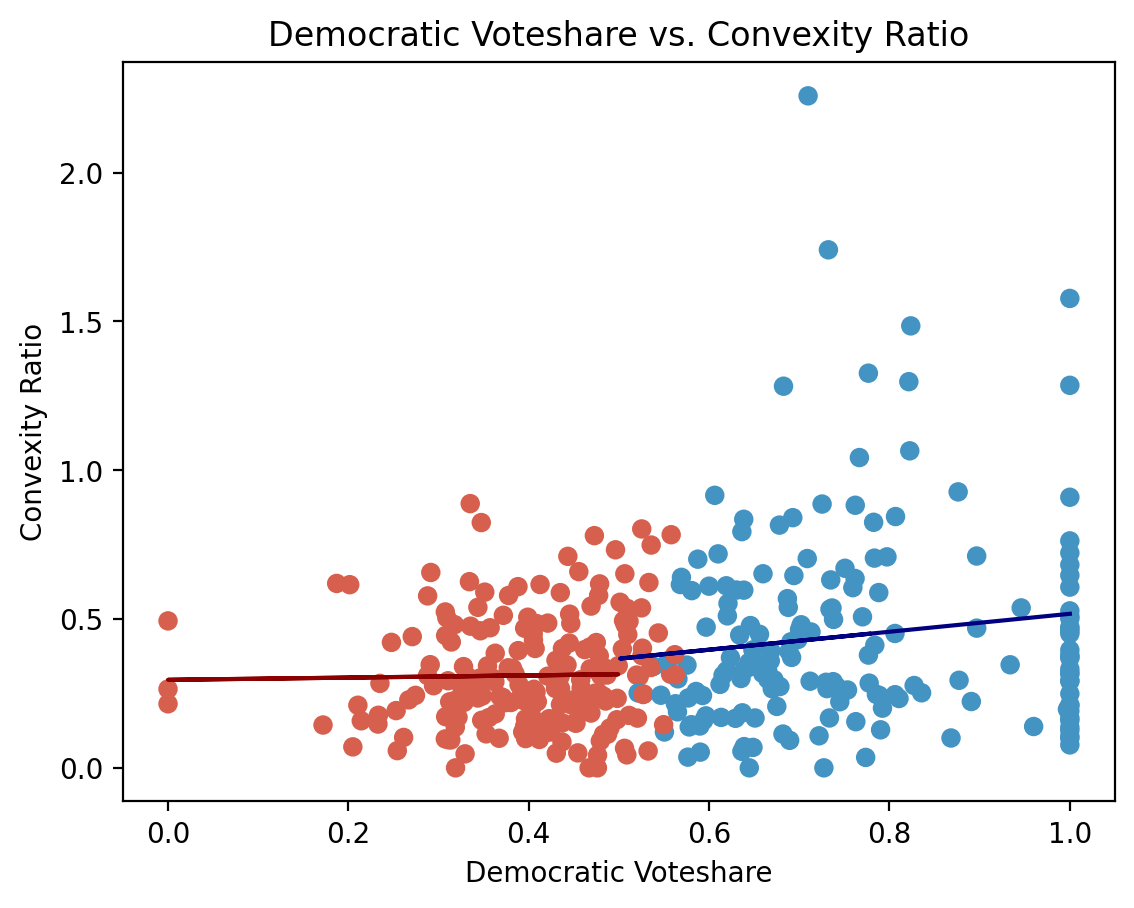

In [15]:
color_map = {"D": 0.8, "R": 0.2}
colors_D = dists_geo[dists_geo["Party"] == "D"]["Incumbent"].map(color_map)
colors_R = dists_geo[dists_geo["Party"] == "R"]["Incumbent"].map(color_map)


x_D = dists_geo[dists_geo["Party"] == "D"][["D Voteshare"]]
y_D = dists_geo[dists_geo["Party"] == "D"][["Ratio"]]
x_R = dists_geo[dists_geo["Party"] == "R"][["D Voteshare"]]
y_R = dists_geo[dists_geo["Party"] == "R"][["Ratio"]]

regressor_D = LinearRegression()
regressor_D.fit(x_D, y_D)
regressor_R = LinearRegression()
regressor_R.fit(x_R, y_R)

plt.scatter(x_D, 
            y_D, 
            c = colors_D, 
            cmap = "RdBu",
            vmin = 0,
            vmax = 1)
plt.plot(x_D, regressor_D.predict(x_D), color = 'navy')
plt.scatter(x_R, 
            y_R, 
            c = colors_R, 
            cmap = "RdBu",
            vmin = 0,
            vmax = 1)
plt.plot(x_R, regressor_R.predict(x_R), color = 'darkred')
plt.xlim(-0.05,1.05)
plt.title("Democratic Voteshare vs. Convexity Ratio")
plt.xlabel("Democratic Voteshare")
plt.ylabel("Convexity Ratio")
plt.show()

Subsection b: diff in diff

In [ ]:
from diff_diff import DifferenceInDifferences

# Fit a basic DiD model
did = DifferenceInDifferences()
results = did.fit(data, outcome='y', treatment='treated', time='post')
print(results.summary())


did = DifferenceInDifferences()
did.fit(dists_geo, y="outcome", treatment="treatment", post="post")

# Display the summary table
print(did.summary())